In [24]:
import torch
from torch import nn
import numpy as np
import torch.nn.functional as F  
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

device = torch.device("cuda")

In [25]:
# 20个变量没有constant
data = np.load("fourcast.npy")
data = data[:,:,:48,:72]
data.shape

(1460, 20, 48, 72)

In [26]:
train_data,test_data = data[:1168],data[1168:]

In [27]:
train_data.shape,test_data.shape

((1168, 20, 48, 72), (292, 20, 48, 72))

In [28]:
mean = np.mean(train_data,keepdims=True,axis=(0,2,3))
std = np.std(train_data,keepdims=True,axis=(0,2,3))
mean.shape,std.shape

((1, 20, 1, 1), (1, 20, 1, 1))

In [29]:
train_data = (train_data - mean) / (std + 1e-6)
test_data = (test_data - mean) / (std + 1e-6)

In [30]:
train_data.mean(),train_data.std(),test_data.mean(),test_data.std()

(np.float64(-4.61438204856889e-16),
 np.float64(0.9999460485883532),
 np.float64(-0.022614229375720295),
 np.float64(1.0066228145107414))

In [31]:
class Loader(Dataset):
    def __init__(self,data,lead_time):
        self.lead_time = lead_time
        self.data = data
    
    def __len__(self):
        return len(self.data) - self.lead_time
    
    def __getitem__(self,idx):
        input_data = torch.tensor(
            self.data[idx],
            dtype = torch.float32
        )
        target_data = torch.tensor(
            self.data[idx+self.lead_time],
            dtype = torch.float32
        )
        return input_data, target_data


In [32]:
dataloader_tr = Loader(train_data,1)
dataloader_te = Loader(test_data,1)

train = torch.utils.data.DataLoader(dataloader_tr,batch_size=24,drop_last=True)
test = torch.utils.data.DataLoader(dataloader_te,batch_size=24,drop_last=True)

In [33]:
for x,y in train:
    print(x.shape)
    print(y.shape)
    break

torch.Size([24, 20, 48, 72])
torch.Size([24, 20, 48, 72])


In [34]:
# 位置编码 直接添加到特征维度
def position(img):
    B,C,H,W = img.shape
    x1 = np.meshgrid(np.sin(np.linspace(0,2*np.pi,H)))
    x2 = np.meshgrid(np.cos(np.linspace(0,2*np.pi,H)))
    y1 = np.meshgrid(np.sin(np.linspace(0,2*np.pi,W)))
    y2 = np.meshgrid(np.cos(np.linspace(0,2*np.pi,W)))
    grid_x1 ,grid_y1 = np.meshgrid(y1,x1)
    grid_x2 ,grid_y2 = np.meshgrid(y2,x2)
    grid = np.expand_dims(np.stack([grid_x1,grid_y1,grid_x2,grid_y2],axis = 0),axis = 0)
    img = torch.concatenate([img,torch.Tensor(grid.repeat(B,axis = 0)).to(device)],axis = 1)
    return img

In [35]:
# 假设input_size是256    256//8=32 每块32
class AFNO2D(nn.Module): 
    def __init__(self,input_size,num_block = 8 ,sparsity_threshold=0.01, hard_thresholding_fraction=1, hidden_size_factor=2):
        super().__init__()
        self.input_size = input_size # 输入维度
        self.num_block = num_block  # 分块大小
        self.sparsity_threshold = sparsity_threshold  # 那个频率压为0
        self.hard_thresholding_fraction = hard_thresholding_fraction # 低频率取值范围
        self.hidden_size_factor = hidden_size_factor # 进行MLP时维度的映射倍率
        self.block_size = input_size // num_block  # 分块后的特征维度
        self.scale = 0.02

                                # 2 是一个实部一个虚部  中间两个是分块    后面self.hidden_size_factor类似于线性映射
        self.w1 = nn.Parameter(self.scale * torch.rand(2, self.num_block,self.block_size,self.block_size * self.hidden_size_factor))
        self.b1 = nn.Parameter(self.scale * torch.rand(2, self.num_block, self.block_size * self.hidden_size_factor))

        self.w2 = nn.Parameter(self.scale * torch.rand(2, self.num_block,self.block_size*self.hidden_size_factor,self.block_size))
        self.b2 = nn.Parameter(self.scale * torch.rand(2, self.num_block,self.block_size))

    def forward(self, x):
        bias = x    

        x = x.float()
        B,H,W,C = x.shape

        x = torch.fft.rfft2(x , dim=(1,2),norm="ortho")    # 二维傅里叶变换 将空间域转化为频率域
        x = x.reshape(B,H,W//2+1,self.num_block,self.block_size)  # W//2+1 是因为对称性压缩频谱 后面可以由前面推出  输出时也是会截断的

        # x变为complex形式 想要MLP 就要对实部和虚部分开进行
        o1_real = torch.zeros([B,H,W//2+1,self.num_block,self.block_size * self.hidden_size_factor],device = x.device)
        o1_imag = torch.zeros([B,H,W//2+1,self.num_block,self.block_size * self.hidden_size_factor],device = x.device)
        o2_real = torch.zeros(x.shape,device=x.device)
        o2_imag = torch.zeros(x.shape,device=x.device) 


        total_modes = H//2+1
        kept_modes = int(total_modes * self.hard_thresholding_fraction)  # 截取H维度上的频率 
        # x[...,block,:]@  w1[block,:,:].T
        o1_real[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes] = F.relu(
            torch.einsum("...bi,bio->...bo", x[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes].real,self.w1[0])-
            torch.einsum("...bi,bio->...bo", x[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes].imag,self.w1[1])+
            self.b1[0]
        )
        o1_imag[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes] = F.relu(
            torch.einsum("...bi,bio->...bo", x[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes].real,self.w1[1])+
            torch.einsum("...bi,bio->...bo", x[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes].imag,self.w1[0])+
            self.b1[1]
        )

        o2_real[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes] = F.relu(
            torch.einsum("...bi,bio->...bo", o1_real[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes],self.w2[0])-
            torch.einsum("...bi,bio->...bo", o1_imag[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes],self.w2[1])+
            self.b2[0]
        )
        o2_imag[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes] = F.relu(
            torch.einsum("...bi,bio->...bo", o1_real[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes],self.w2[1])+
            torch.einsum("...bi,bio->...bo", o1_imag[:,total_modes-kept_modes:total_modes+kept_modes,:kept_modes],self.w2[0])+
            self.b2[1]
        )

        x = torch.stack([o2_real,o2_imag],dim = -1)  # 添加一个新维度 是实部与虚部的区分
        x = F.softshrink(x, lambd=self.sparsity_threshold)  # 小频率压为 0 但是其他非小频率也会进行-self.sparsity_threshold
        x = torch.view_as_complex(x) # 将复数形式的数据合并
        x = x.reshape(B, H, W // 2 + 1, C)  # 合并分块
        x = torch.fft.irfft2(x, s=(H, W), dim=(1,2), norm="ortho")  # 逆傅里叶变换 转换为空间域
        return x + bias

In [36]:
class patchembedding(torch.nn.Module):
    def __init__(self,in_channel = 24 ,out_channel = 512,patch_size = (2,2)):
        super().__init__()
        self.c2d = torch.nn.Conv2d(in_channel,out_channel,kernel_size=patch_size,stride=patch_size)
    
    def forward(self,data):
        # 输入B,C,H,W
        data = self.c2d(data)
        data = data.permute(0,2,3,1)
        return data.reshape(data.shape[0],data.shape[1],data.shape[2],data.shape[-1]) # 输出B,H,W,C


In [37]:
class MLP(torch.nn.Module):
    def __init__(self,in_dim,hid_dim,out_dim,act_factor = nn.GELU(),drop_rate = 0):
        super().__init__()
        self.liner1 = nn.Linear(in_dim,hid_dim)
        self.liner2 = nn.Linear(hid_dim,out_dim)
        self.act = act_factor  # 激活层为网络引入非线性
        self.drop = nn.Dropout(drop_rate)

    def forward(self,x):
        x = self.drop(self.act(self.liner1(x)))
        x = self.drop((self.liner2(x)))
        return x 
        

In [38]:
class model_block(torch.nn.Module):
    def __init__(self,input_size,num_block = 8):
        super().__init__()
        self.norm1 = torch.nn.LayerNorm(input_size)
        self.afno = AFNO2D(input_size,num_block)
        self.norm2 = torch.nn.LayerNorm(input_size)
        self.linear = MLP(input_size,input_size * 2,input_size)

    def forward(self,x):
        bias = x 
        
        x = self.norm1(x)
        x = self.afno(x)
        x = bias + x
        bias = x
        x = self.norm2(x)
        x = self.linear(x)

        return x + bias

In [39]:
class patchrevocer(torch.nn.Module):
    def __init__(self,in_channel = 512 ,out_channel = 20,patch_size = (2,2)):
        super().__init__()
        # self.c2d = torch.nn.ConvTranspose2d(in_channel,out_channel,kernel_size=patch_size,stride=patch_size)
        self.pred_head = nn.Sequential(
                # 把 token 通道 D 先压到64，避免内存爆
                nn.Conv2d(in_channel, 64, kernel_size=1, bias=False),
                nn.GELU(),
                nn.GroupNorm(8, 64),

                # 
                nn.ConvTranspose2d(64, 64, kernel_size=patch_size, stride=patch_size, bias=False),
                nn.GELU(),
                nn.GroupNorm(8, 64),

                nn.Conv2d(64, out_channel, kernel_size=3, padding=1, bias=True),
            )
        # 网格域细化（3D 卷积，稳定起见用 GroupNorm 而不是 BN）
        self.refine2d = nn.Sequential(
            nn.Conv2d(out_channel, 16, kernel_size=3, padding=1), 
            nn.GELU(),
            nn.GroupNorm(4, 16),
            nn.Conv2d(16, out_channel, kernel_size=1),
        )
    def forward(self,data):
        data = data.permute(0,3,1,2)
        data = self.pred_head(data)
        data = self.refine2d(data)
        return data

In [40]:
class fourcastmodel(torch.nn.Module):
    def __init__(self,blocks,input_size,num_block = 8):
        super().__init__()
        self.block = []
        self.blocks = blocks
        self.pos = position
        self.patchembedding = patchembedding()
    
        for i in range(blocks):
            self.block.append(model_block(input_size,num_block))
        self.block = nn.ModuleList(self.block)

        self.mlp = MLP(512,1024,512)
        self.patctecover = patchrevocer()
    def forward(self,x):
        x = self.pos(x)
        x = self.patchembedding(x)
        for i in range(self.blocks):
            x = self.block[i](x)
        x = self.mlp(x)
        x = self.patctecover(x)
        return x

In [41]:
model = fourcastmodel(6,512,8)
optimier = torch.optim.Adam(model.parameters(),lr=1e-4,weight_decay=1e-5)
loss_fun = torch.nn.MSELoss()
epochs = 200
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimier,T_max=epochs, eta_min=1e-6)
model = model.to(device)
train_loss = []
test_loss = []
best_score = 100.0

In [19]:
for epoch in range(epochs):
    
    model.train()
    train_total_loss = 0.0
    test_total_loss = 0.0
    loss = 0
    for input_,target in train:
        input_ = input_.to(device)
        target= target.to(device)

        out = model(input_)

        loss = loss_fun(out,target)

        optimier.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimier.step()
        train_total_loss+=loss.item()

    train_loss.append(train_total_loss/len(train))
    model.eval() 
    with torch.no_grad():
        for input_,target in test:
            input_ = input_.to(device)
            target= target.to(device)

            out = model(input_)

            loss = loss_fun(out,target)

            test_total_loss+=loss.item()

        test_loss.append(test_total_loss/len(test))
        scheduler.step()
        if best_score > test_loss[-1]:
            torch.save( model.state_dict(),"best_model.pth")
            best_score = test_loss[-1]
        current_lr = optimier.param_groups[0]["lr"]
        print(f"epoch:{epoch+1}的train_loss,test_loss：{train_loss[epoch],test_loss[epoch]}，lr：{current_lr}")
plt.close('all') 
plt.plot(train_loss, color='blue', label='Train Loss')
plt.plot(test_loss, color='red', label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xlim(1, epochs)   
plt.title("Training And Testing Loss Curve")
plt.show()

KeyboardInterrupt: 

In [42]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

9068248


In [43]:
dicts = torch.load("best_model.pth")
model.load_state_dict(dicts)

<All keys matched successfully>

In [44]:
def weighted_acc_simple(
    pred,
    target
):
    pred = pred.reshape(pred.shape[0],-1)
    target = target.reshape(target.shape[0],-1)

    pred = pred - pred.mean(dim=1,keepdim=True)
    target = target - target.mean(dim=1,keepdim=True)

    numerator = (pred*target).sum(dim=1)

    denominator = torch.sqrt(
        (pred**2).sum(dim=1)
        *
        (target**2).sum(dim=1)
    )

    acc = numerator/(denominator+1e-8)

    return acc.mean()

In [54]:
model.eval()


surface_vars = {
    "U10":0,
    "V10":1,
    "T2M":2,
    "MSL":3,
    "U1000":4,
    "U850":5,
    "U500":6,
    "U250":7,
    "V1000":8,
    "V850":9,
    "V500":10,
    "V250":11,
    "Z1000":12,
    "Z850":13,
    "Z500":14,
    "Z250":15,
    "T850":16,
    "Q1000":17,
    "Q850":18,
    "Q500":19,
}
metrics = {}

for name in list(surface_vars.keys()):

    metrics[name] = {
        "rmse": [],
        "mae": [],
        "acc": []
    }

with torch.no_grad():

    for lead in range(1,2):

        print(f"\nEvaluating {lead*6}h")

        dataset = Loader(
            test_data,lead
        )

        test_loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=48,
            shuffle=False,
            drop_last=True
        )

        rmse_sum = {
            name:0.0
            for name in metrics
        }

        mae_sum = {
            name:0.0
            for name in metrics
        }

        acc_sum = {
            name:0.0
            for name in metrics
        }

        for input_,target in test_loader:

            input_ = input_.to(device)

            target = target.to(device)

            preds = input_ 
            # autoregressive rollout
            for _ in range(lead):

                preds= model( preds )
            # ------------------
            # 反归一化
            # ------------------


            preds = (
                preds.to("cpu") * std + mean
            )

            target = (
                target.to("cpu")  * std + mean
            )

            # ======================
            # Surface
            # ======================

            for name,var_idx in surface_vars.items():

                pred = preds[:,var_idx]
                truth = target[:,var_idx]

                rmse = torch.sqrt(
                    torch.mean(
                        (pred-truth)**2
                    )
                )

                mae = torch.mean(
                    torch.abs(
                        pred-truth
                    )
                )
                # print(pred.shape,truth.shape)
                acc = weighted_acc_simple(
                    pred,
                    truth
                )

                rmse_sum[name] += rmse.item()
                mae_sum[name] += mae.item()
                acc_sum[name] += acc.item()

        # 保存当前lead结果

        for name in metrics:

            metrics[name]["rmse"].append(
                rmse_sum[name] / len(test_loader)
            )

            metrics[name]["mae"].append(
                mae_sum[name] / len(test_loader)
            )

            metrics[name]["acc"].append(
                acc_sum[name] / len(test_loader)
            )


Evaluating 6h


/tmp/ipykernel_7799/2775942908.py:85: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  preds.to("cpu") * std + mean
/tmp/ipykernel_7799/2775942908.py:89: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  target.to("cpu")  * std + mean


In [55]:
import matplotlib.pyplot as plt
import numpy as np

up_vars = [  
    "U10",
    "V10",
    "T2M",
    "MSL",
    "U1000",
    "U850",
    "U500",
    "U250",
    "V1000",
    "V850",
    "V500",
    "V250",
    "Z1000",
    "Z850",
    "Z500",
    "Z250",
    "T850",
    "Q1000",
    "Q850",
    "Q500"]

sample_idx = 5 

fig, axes = plt.subplots(len(up_vars),3, figsize=(120,180))

for i,var in enumerate(up_vars):

    truth = target[sample_idx,i].cpu().numpy()

    pred = preds[sample_idx,i].detach().cpu().numpy()

    error = pred - truth

    vmax = max(np.max(truth),np.max(pred))

    vmin = min(np.min(truth), np.min(pred))

    axes[i,0].imshow(truth,cmap="jet", vmin=vmin, vmax=vmax )
    axes[i,0].set_title( f"{var} Truth" )

    axes[i,1].imshow( pred, cmap="jet", vmin=vmin, vmax=vmax)
    axes[i,1].set_title(f"{var} Prediction")

    axes[i,2].imshow(error,cmap="RdBu_r")
    axes[i,2].set_title(f"{var} Error")

plt.tight_layout()
plt.show()

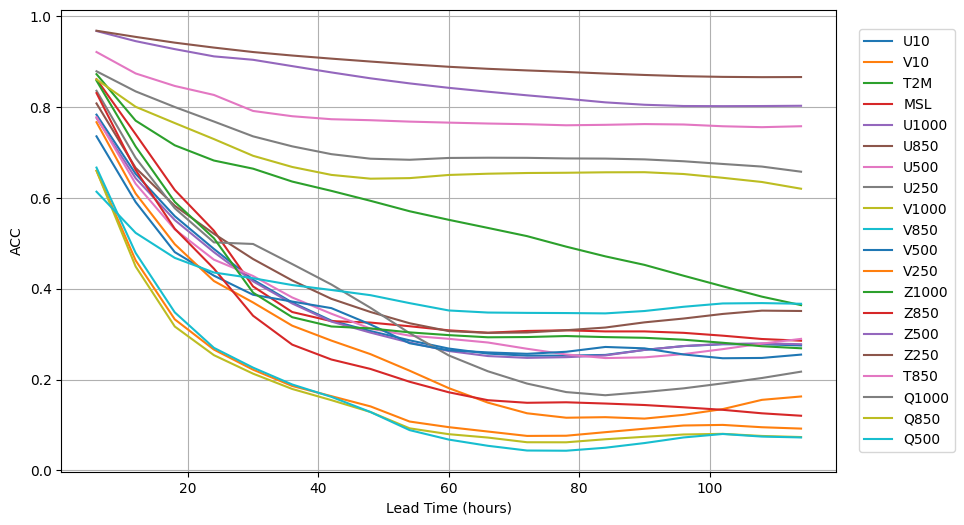

In [53]:
lead_time = np.arange(1,20) * 6

plt.figure(figsize=(10,6))




for var in [
   "U10",
    "V10",
    "T2M",
    "MSL",
    "U1000",
    "U850",
    "U500",
    "U250",
    "V1000",
    "V850",
    "V500",
    "V250",
    "Z1000",
    "Z850",
    "Z500",
    "Z250",
    "T850",
    "Q1000",
    "Q850",
    "Q500"
]:

    plt.plot(
        lead_time,
        metrics[var]["acc"],
        label=var
    )

plt.xlabel("Lead Time (hours)")
plt.ylabel("ACC")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.grid()

plt.show()